# Marketing Campaign Performance Analysis


This project analyzes marketing campaign performance using metrics such as ROI, conversion rate, engagement score, and acquisition cost to identify the most effective marketing strategies.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


### Exploratory Data Analysis (EDA)

In [2]:
df=pd.read_csv("D:\intern\data\marketing_campaign_dataset.csv")

print(df.head())

   Campaign_ID              Company Campaign_Type Target_Audience Duration  \
0            1  Innovate Industries         Email       Men 18-24  30 days   
1            2       NexGen Systems         Email     Women 35-44  60 days   
2            3    Alpha Innovations    Influencer       Men 25-34  30 days   
3            4   DataTech Solutions       Display        All Ages  60 days   
4            5       NexGen Systems         Email       Men 25-34  15 days   

  Channel_Used  Conversion_Rate Acquisition_Cost   ROI     Location  Language  \
0   Google Ads             0.04       $16,174.00  6.29      Chicago   Spanish   
1   Google Ads             0.12       $11,566.00  5.61     New York    German   
2      YouTube             0.07       $10,200.00  7.18  Los Angeles    French   
3      YouTube             0.11       $12,724.00  5.55        Miami  Mandarin   
4      YouTube             0.05       $16,452.00  6.50  Los Angeles  Mandarin   

   Clicks  Impressions  Engagement_Score    

In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Campaign_ID       200000 non-null  int64  
 1   Company           200000 non-null  object 
 2   Campaign_Type     200000 non-null  object 
 3   Target_Audience   200000 non-null  object 
 4   Duration          200000 non-null  object 
 5   Channel_Used      200000 non-null  object 
 6   Conversion_Rate   200000 non-null  float64
 7   Acquisition_Cost  200000 non-null  object 
 8   ROI               200000 non-null  float64
 9   Location          200000 non-null  object 
 10  Language          200000 non-null  object 
 11  Clicks            200000 non-null  int64  
 12  Impressions       200000 non-null  int64  
 13  Engagement_Score  200000 non-null  int64  
 14  Customer_Segment  200000 non-null  object 
 15  Date              200000 non-null  object 
dtypes: float64(2), int64

In [25]:
df["Campaign_Type"].value_counts()

Influencer      40169
Search          40157
Display         39987
Email           39870
Social Media    39817
Name: Campaign_Type, dtype: int64

In [26]:
df["Channel_Used"].value_counts()

Email         33599
Google Ads    33438
YouTube       33392
Instagram     33392
Website       33360
Facebook      32819
Name: Channel_Used, dtype: int64

--> The dataset contains 200,000 marketing campaign records.

--> It includes 16 variables describing campaign performance.

--> The data captures campaign type, marketing channel, audience, engagement metrics, and financial performance.

In [5]:
print(df.describe())

         Campaign_ID  Conversion_Rate            ROI         Clicks  \
count  200000.000000    200000.000000  200000.000000  200000.000000   
mean   100000.500000         0.080070       5.002438     549.772030   
std     57735.171256         0.040602       1.734488     260.019056   
min         1.000000         0.010000       2.000000     100.000000   
25%     50000.750000         0.050000       3.500000     325.000000   
50%    100000.500000         0.080000       5.010000     550.000000   
75%    150000.250000         0.120000       6.510000     775.000000   
max    200000.000000         0.150000       8.000000    1000.000000   

         Impressions  Engagement_Score  
count  200000.000000     200000.000000  
mean     5507.301520          5.494710  
std      2596.864286          2.872581  
min      1000.000000          1.000000  
25%      3266.000000          3.000000  
50%      5517.500000          5.000000  
75%      7753.000000          8.000000  
max     10000.000000         10.

In [22]:
df.isnull().sum()

Campaign_ID         0
Company             0
Campaign_Type       0
Target_Audience     0
Duration            0
Channel_Used        0
Conversion_Rate     0
Acquisition_Cost    0
ROI                 0
Location            0
Language            0
Clicks              0
Impressions         0
Engagement_Score    0
Customer_Segment    0
Date                0
dtype: int64

--> The dataset was checked for missing values using isnull().sum().

--> No missing values were found across any columns.

--> Therefore, no imputation or removal of rows was required.

## Which Campaign Type Generates the Highest ROI?


In [8]:
category_roi= df.groupby("Campaign_Type")["ROI"].mean().sort_values(ascending=True)

In [9]:
print(category_roi)

Campaign_Type
Social Media    4.991784
Email           4.994295
Display         5.006551
Search          5.008357
Influencer      5.011068
Name: ROI, dtype: float64


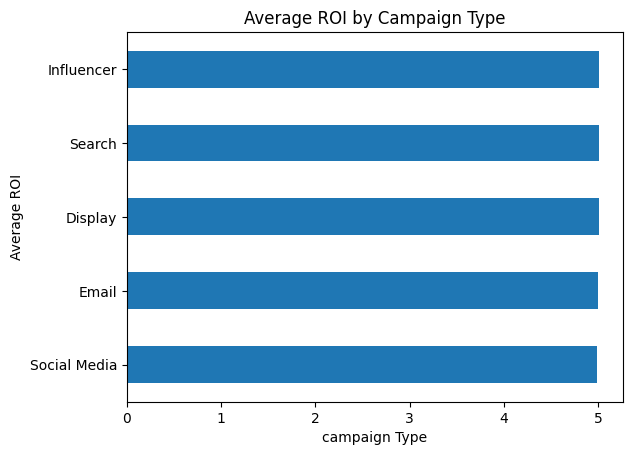

In [12]:
category_roi.sort_values().plot(kind="barh")

plt.title("Average ROI by Campaign Type")
plt.ylabel("Average ROI")
plt.xlabel("campaign Type")

plt.show()

FINDINGS:

--> Influencer campaigns show the highest average ROI (≈5.01).

--> Search and Display campaigns also perform well with ROI slightly above 5.

--> Email and Social Media campaigns show slightly lower ROI.

OBSERVATION:

--> The ROI differences across campaign types are very small.

--> This indicates that campaign performance is fairly balanced across marketing strategies.

## Which Marketing Channel Generates the Highest Engagement?

In [15]:
channel_engagement= df.groupby("Channel_Used")["Engagement_Score"].mean().sort_values(ascending=False)
print(channel_engagement)

Channel_Used
Website       5.508903
Facebook      5.503702
Google Ads    5.494049
Instagram     5.489039
Email         5.487842
YouTube       5.484937
Name: Engagement_Score, dtype: float64


FINDINGS:

--> Website and Facebook channels show the highest engagement scores.

--> Google Ads and Instagram also maintain strong engagement levels.

--> Email and YouTube show slightly lower engagement.

## Which Customer Segment Has the Highest Conversion Rate?

In [18]:
segment_conversion = df.groupby("Customer_Segment")["Conversion_Rate"].mean().sort_values(ascending=False)
print(segment_conversion)

Customer_Segment
Foodies                0.080257
Outdoor Adventurers    0.080180
Tech Enthusiasts       0.080168
Health & Wellness      0.079945
Fashionistas           0.079794
Name: Conversion_Rate, dtype: float64


FINDING: The Foodies segment shows the highest conversion rate (8.02%), followed closely by Outdoor Adventurers and Tech Enthusiasts.

## Which Campaign Type Provides the Best ROI?


In [20]:
campaign_efficency= df.groupby("Campaign_Type")["ROI"].mean()
print(campaign_efficency)

                    ROI
Campaign_Type          
Display        5.006551
Email          4.994295
Influencer     5.011068
Search         5.008357
Social Media   4.991784


C:\Users\Naveen\AppData\Local\Temp\ipykernel_8144\3175031405.py:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  campaign_efficency= df.groupby("Campaign_Type")[["ROI","Acquisition_Cost"]].mean()


FINDING: Influencer campaigns generate the highest average ROI (5.011) among all campaign types.

## Which Location Performs Best for Marketing Campaigns?

In [24]:
location_performance = df.groupby("Location")[["ROI","Conversion_Rate"]].mean().sort_values(by="ROI", ascending=False)

print(location_performance)

                  ROI  Conversion_Rate
Location                              
Miami        5.012282         0.080047
Los Angeles  5.010876         0.080013
Houston      5.007203         0.079948
Chicago      5.001590         0.080134
New York     4.980228         0.080204


FINDINGS:

--> Miami shows the highest average ROI (5.012) among all locations, followed closely by Los Angeles and Houston.
--> Marketing performance is relatively consistent across locations, with only minor differences between cities.

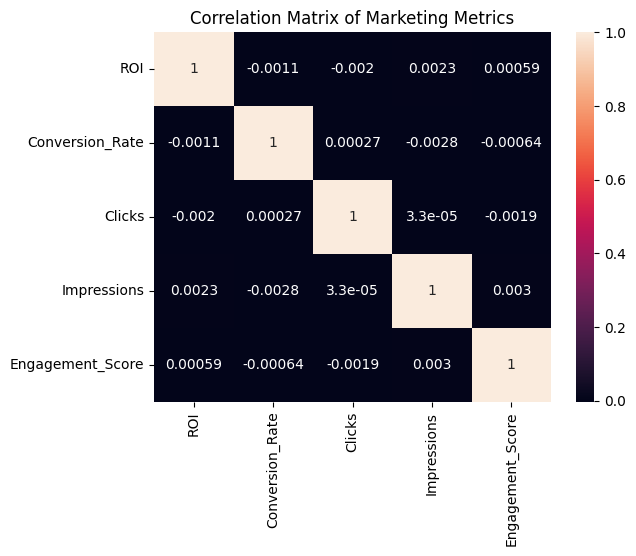

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df[["ROI","Conversion_Rate","Clicks","Impressions","Engagement_Score"]].corr()

sns.heatmap(corr, annot=True)

plt.title("Correlation Matrix of Marketing Metrics")
plt.show()

Key Findings

--> ROI and Conversion Rate show almost no correlation (-0.0011).

--> Clicks and Impressions also have almost zero relationship.

--> Engagement Score has very weak relationships with all other variables.

--> Most correlation values are very close to 0.

The correlation matrix indicates that marketing performance metrics in this dataset do not show strong linear relationships, suggesting that campaign success may depend on multiple independent factors rather than a single dominant variable.

Final Conclusion

--> Overall, the marketing campaign performance appears balanced across campaign types, channels, customer segments, and locations.

--> No single factor strongly dominates campaign success.

--> This suggests that multiple factors together influence marketing performance rather than one single metric